In [1]:
!pip install scanpy
!pip install scanpy
!pip install magic-impute

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.1 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.2
    Uninstalling matplotlib-3.7.2:
      Successfully uninstalled matplotlib-3.7.2
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.4
    Uninstalling statsmodels-0.1

# RAW Before Imputation

Original gene expression shape: (16263, 19639)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
2026-02-22 19:12:14.239977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771787534.443717      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771787534.507737      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
... storing 'kmeans' as categorical


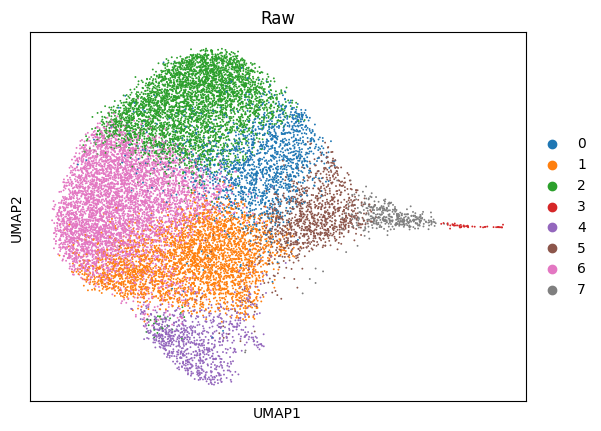

ARI (Adjusted Rand Index) on raw data (KMeans): 0.1679
Percentage of 0s in raw gene expression: 84.65%


In [2]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# ========== Step 1: Load Data ==========
adata = sc.read_h5ad("/kaggle/input/stereo-seq/stereo-seq/FB2_D1_stereo-seq_processed.h5ad")

# Backup raw data
adata.raw = adata

# Gene Expression & Coordinates
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']
print("Original gene expression shape:", X.shape)

# ========== Step 2: KMeans Clustering on Raw ==========
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)

# Perform KMeans on PCA representation
X_pca = adata.obsm["X_pca"]
kmeans = KMeans(n_clusters=8, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(X_pca).astype(str)

# UMAP for visualization
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)

# Plot Clustering
sc.pl.umap(adata, color="kmeans", title="Raw")

# Evaluate with ARI if ground truth exists
if "annotation" in adata.obs.columns:
    ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
    print(f"ARI (Adjusted Rand Index) on raw data (KMeans): {ari:.4f}")
else:
    print("'annotation' ground truth not found in adata.obs.")

# Zero Percentage
zero_pct = 100 * (X == 0).sum() / X.size
print(f"Percentage of 0s in raw gene expression: {zero_pct:.2f}%")


In [3]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset

# ========= Load and Prepare =========
adata = sc.read_h5ad("/kaggle/input/stereo-seq/stereo-seq/FB2_D1_stereo-seq_processed.h5ad")
adata.raw = adata
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']

if "annotation" not in adata.obs.columns:
    raise ValueError("No ground truth label 'annotation' found!")

# Limit to top 3000 genes for memory
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var.highly_variable]

X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']

# ========== Torch Setup ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
coords_tensor = torch.tensor(coords, dtype=torch.float32, device=device)

# ========== Attention Module ==========
class AdvancedSpatialAttention(nn.Module):
    def __init__(self, input_dim=2, embed_dim=32, heads=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

    def forward(self, coords):
        x = self.embedding(coords)
        x = x.unsqueeze(0)
        return self.encoder(x).squeeze(0)

# ========== Imputer ==========
class FusionImputer(nn.Module):
    def __init__(self, gene_dim, spatial_dim):
        super().__init__()
        fused_dim = gene_dim + spatial_dim
        self.encoder = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, gene_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ========== Initialize ==========
attn = AdvancedSpatialAttention(embed_dim=32).to(device)
projector = nn.Linear(32, X_tensor.shape[1]).to(device)
model = FusionImputer(gene_dim=X_tensor.shape[1], spatial_dim=X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(list(attn.parameters()) + list(projector.parameters()) + list(model.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

# ========== Precompute Attention Features ==========
attn.eval()
with torch.no_grad():
    spatial_feat = attn(coords_tensor)
    spatial_proj = projector(spatial_feat)

# ========== Prepare Dataloader ==========
batch_size = 256
fused_data = torch.cat([X_tensor, spatial_proj], dim=1)
dataset = TensorDataset(fused_data, X_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ========== Training Loop ==========
model.train()
for epoch in range(50):
    total_loss = 0
    for batch_x, batch_target in loader:
        # Simulate dropout
        mask = (torch.rand_like(batch_target) > 0.2).float()
        batch_dropout = batch_target * mask

        # Fused dropout input
        fused_dropout = torch.cat([batch_dropout, spatial_proj[:batch_x.size(0)]], dim=1)

        # Forward + Backward
        optimizer.zero_grad()
        out = model(fused_dropout)
        loss = loss_fn(out, batch_target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")

# ========== Inference ==========
model.eval()
with torch.no_grad():
    full_fused = torch.cat([X_tensor, spatial_proj], dim=1)
    imputed = model(full_fused).cpu().numpy()




Epoch 0: Avg Loss = 0.1419
Epoch 1: Avg Loss = 0.1238
Epoch 2: Avg Loss = 0.1236
Epoch 3: Avg Loss = 0.1223
Epoch 4: Avg Loss = 0.1213
Epoch 5: Avg Loss = 0.1206
Epoch 6: Avg Loss = 0.1200
Epoch 7: Avg Loss = 0.1196
Epoch 8: Avg Loss = 0.1191
Epoch 9: Avg Loss = 0.1188
Epoch 10: Avg Loss = 0.1185
Epoch 11: Avg Loss = 0.1174
Epoch 12: Avg Loss = 0.1131
Epoch 13: Avg Loss = 0.1129
Epoch 14: Avg Loss = 0.1126
Epoch 15: Avg Loss = 0.1122
Epoch 16: Avg Loss = 0.1119
Epoch 17: Avg Loss = 0.1117
Epoch 18: Avg Loss = 0.1113
Epoch 19: Avg Loss = 0.1111
Epoch 20: Avg Loss = 0.1077
Epoch 21: Avg Loss = 0.1063
Epoch 22: Avg Loss = 0.1060
Epoch 23: Avg Loss = 0.1058
Epoch 24: Avg Loss = 0.1055
Epoch 25: Avg Loss = 0.1052
Epoch 26: Avg Loss = 0.1051
Epoch 27: Avg Loss = 0.1049
Epoch 28: Avg Loss = 0.1042
Epoch 29: Avg Loss = 0.1027
Epoch 30: Avg Loss = 0.1022
Epoch 31: Avg Loss = 0.1019
Epoch 32: Avg Loss = 0.1017
Epoch 33: Avg Loss = 0.1017
Epoch 34: Avg Loss = 0.1015
Epoch 35: Avg Loss = 0.1013
Ep

# Spatial Attention + PCA (Without SpatialMAGIC)

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_20/1819799127.py:1: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  adata.X = imputed
/tmp/ipykernel_20/1819799127.py:1: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = imputed
/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans

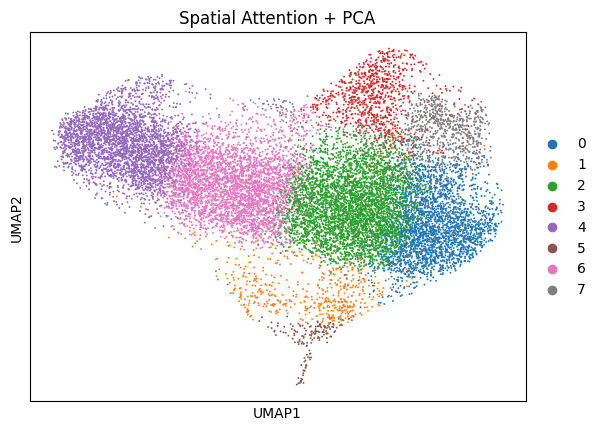

🎯 ARI after Imputation (KMeans): 0.2580
🧊 Zero % after Imputation: 82.44%


In [4]:
adata.X = imputed

# ----- PCA -----
sc.pp.pca(adata, n_comps=50)
pca_result = adata.obsm["X_pca"]

# ----- KMeans Clustering -----
kmeans = KMeans(n_clusters=8, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(pca_result).astype(str)

# ----- UMAP for Visualization -----
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
sc.pl.umap(adata, color="kmeans", title="Spatial Attention + PCA")

# ----- Evaluation -----
ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
print(f"🎯 ARI after Imputation (KMeans): {ari:.4f}")

zero_pct = 100 * (imputed == 0).sum() / imputed.size
print(f"🧊 Zero % after Imputation: {zero_pct:.2f}%")

# Spatial Attention + UMAP (Without SpatialMAGIC)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
... storing 'kmeans' as categorical


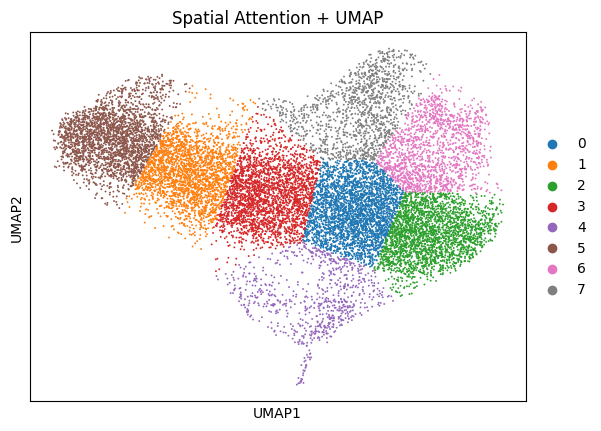

🎯 ARI after Imputation (KMeans on UMAP): 0.2543
🧊 Zero % after Imputation: 82.44%


In [5]:
adata.X = imputed

# ----- Neighbors and UMAP -----
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Use UMAP embedding directly for clustering
umap_result = adata.obsm["X_umap"]

# ----- KMeans Clustering on UMAP -----
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=8, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(umap_result).astype(str)

# ----- Visualization -----
sc.pl.umap(adata, color="kmeans", title="Spatial Attention + UMAP")

# ----- Evaluation -----
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
print(f"🎯 ARI after Imputation (KMeans on UMAP): {ari:.4f}")

zero_pct = 100 * (imputed == 0).sum() / imputed.size
print(f"🧊 Zero % after Imputation: {zero_pct:.2f}%")


# Only MAGIC

Original gene expression shape: (16263, 19639)
⏱ [Step 1: Load Data] Runtime: 6.06s
⏱ [Step 2a: Normalize & Log1p] Runtime: 0.46s
Calculating MAGIC...
  Running MAGIC on 16263 cells and 19639 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 11.66 seconds.
    Calculating KNN search...
    Calculated KNN search in 1.16 seconds.
    Calculating affinities...
    Calculated affinities in 2.51 seconds.
  Calculated graph and diffusion operator in 15.36 seconds.
  Running MAGIC with `solver='exact'` on 19639-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 193.48 seconds.
Calculated MAGIC in 209.06 seconds.
⏱ [Step 2b: MAGIC Imputation] Runtime: 209.06s
⏱ [Step 3a: PCA] Runtime: 52.65s


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


⏱ [Step 3b: KMeans Clustering] Runtime: 0.54s


... storing 'kmeans_magic' as categorical


⏱ [Step 3c: Neighbors & UMAP] Runtime: 13.20s


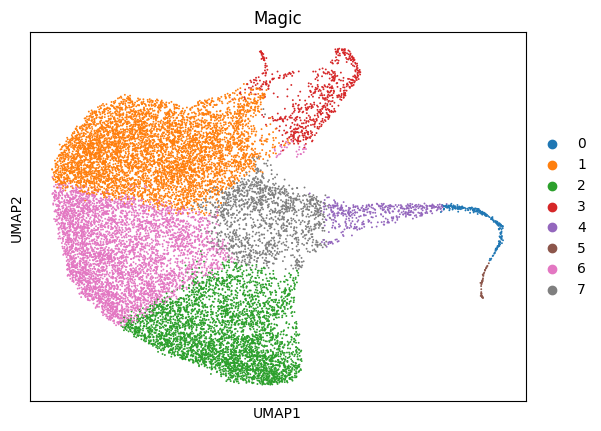

⏱ [Step 3d: UMAP Plot] Runtime: 0.29s
ARI (Adjusted Rand Index) after MAGIC: 0.2192
⏱ [Step 4: ARI Evaluation] Runtime: 0.03s
Percentage of 0s in raw gene expression (before MAGIC): 84.65%
⏱ [Step 5: Zero % Calculation] Runtime: 0.62s

STEP                                TIME (s)
Step 1: Load Data                       6.06s
Step 2a: Normalize & Log1p              0.46s
Step 2b: MAGIC Imputation             209.06s
Step 3a: PCA                           52.65s
Step 3b: KMeans Clustering              0.54s
Step 3c: Neighbors & UMAP              13.20s
Step 3d: UMAP Plot                      0.29s
Step 4: ARI Evaluation                  0.03s
Step 5: Zero % Calculation              0.62s
---------------------------------------------
TOTAL                                 282.91s


In [6]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
import magic
import time  # ← Added

# ========== Runtime Tracker ==========
step_times = {}

def start_timer():
    return time.time()

def end_timer(start, step_name):
    elapsed = time.time() - start
    step_times[step_name] = elapsed
    print(f"⏱ [{step_name}] Runtime: {elapsed:.2f}s")

def print_summary():
    print("\n" + "="*45)
    print(f"{'STEP':<35} {'TIME (s)':>8}")
    print("="*45)
    total = 0
    for step, t in step_times.items():
        print(f"{step:<35} {t:>8.2f}s")
        total += t
    print("-"*45)
    print(f"{'TOTAL':<35} {total:>8.2f}s")
    print("="*45)

# ========== Step 1: Load Data ==========
t = start_timer()

adata = sc.read_h5ad("/kaggle/input/stereo-seq/stereo-seq/FB2_D1_stereo-seq_processed.h5ad")
adata.raw = adata
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else adata.X
coords = adata.obsm['spatial']
print("Original gene expression shape:", X.shape)

end_timer(t, "Step 1: Load Data")

# ========== Step 2: Apply MAGIC Imputation ==========
t = start_timer()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

end_timer(t, "Step 2a: Normalize & Log1p")

t = start_timer()

magic_op = magic.MAGIC()
X_magic = magic_op.fit_transform(X)
adata.layers["magic"] = X_magic
adata.X = X_magic

end_timer(t, "Step 2b: MAGIC Imputation")

# ========== Step 3: PCA, KMeans, UMAP ==========
t = start_timer()
sc.pp.pca(adata)
X_pca = adata.obsm["X_pca"]
end_timer(t, "Step 3a: PCA")

t = start_timer()
kmeans = KMeans(n_clusters=8, random_state=42)
adata.obs["kmeans_magic"] = kmeans.fit_predict(X_pca).astype(str)
end_timer(t, "Step 3b: KMeans Clustering")

t = start_timer()
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
end_timer(t, "Step 3c: Neighbors & UMAP")

t = start_timer()
sc.pl.umap(adata, color="kmeans_magic", title="Magic")
end_timer(t, "Step 3d: UMAP Plot")

# ========== Step 4: Evaluation ==========
t = start_timer()

if "annotation" in adata.obs.columns:
    ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans_magic"])
    print(f"ARI (Adjusted Rand Index) after MAGIC: {ari:.4f}")
else:
    print("'annotation' ground truth not found in adata.obs.")

end_timer(t, "Step 4: ARI Evaluation")

# ========== Step 5: Zero Percentage Before MAGIC ==========
t = start_timer()

zero_pct = 100 * (X == 0).sum() / X.size
print(f"Percentage of 0s in raw gene expression (before MAGIC): {zero_pct:.2f}%")

end_timer(t, "Step 5: Zero % Calculation")

# ========== Final Runtime Summary ==========
print_summary()

# SpatialMAGIC

⏱ [Step 1: Load & Prepare Data] Runtime: 8.48s
Applying MAGIC imputation...
⏱ [Step 2: MAGIC Imputation] Runtime: 275.78s
⏱ [Step 3: Tensor Setup] Runtime: 0.13s
⏱ [Step 4: Model Initialization] Runtime: 0.04s
⏱ [Step 5: Spatial Attention Precompute] Runtime: 0.00s
⏱ [Step 6: DataLoader Preparation] Runtime: 0.00s
Training neural network...
Epoch 0: Avg Loss = 0.0376
Epoch 1: Avg Loss = 0.0312
Epoch 2: Avg Loss = 0.0288
Epoch 3: Avg Loss = 0.0280
Epoch 4: Avg Loss = 0.0276
Epoch 5: Avg Loss = 0.0269
Epoch 6: Avg Loss = 0.0260
Epoch 7: Avg Loss = 0.0235
Epoch 8: Avg Loss = 0.0228
Epoch 9: Avg Loss = 0.0228
Epoch 10: Avg Loss = 0.0228
Epoch 11: Avg Loss = 0.0227
Epoch 12: Avg Loss = 0.0202
Epoch 13: Avg Loss = 0.0185
Epoch 14: Avg Loss = 0.0184
Epoch 15: Avg Loss = 0.0184
Epoch 16: Avg Loss = 0.0183
Epoch 17: Avg Loss = 0.0183
Epoch 18: Avg Loss = 0.0182
Epoch 19: Avg Loss = 0.0181
Epoch 20: Avg Loss = 0.0180
Epoch 21: Avg Loss = 0.0180
Epoch 22: Avg Loss = 0.0179
Epoch 23: Avg Loss = 0.

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_20/4022121703.py:256: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  adata.X = final_imputed
/tmp/ipykernel_20/4022121703.py:256: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = final_imputed


⏱ [Step 8: Inference] Runtime: 1.94s


/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


⏱ [Step 9a: PCA] Runtime: 5.20s


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


⏱ [Step 9b: KMeans Clustering] Runtime: 0.55s


... storing 'kmeans' as categorical


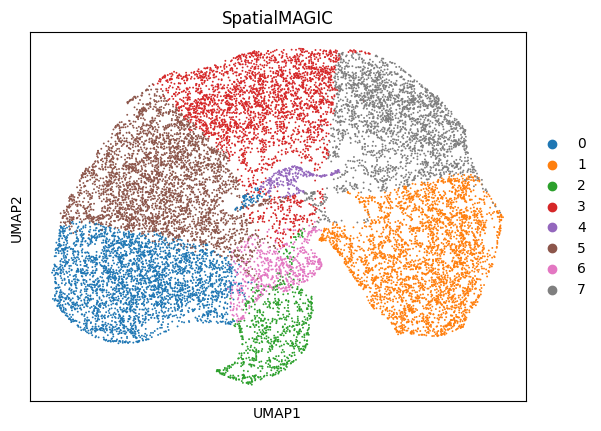

⏱ [Step 9c: Neighbors, UMAP & Plot] Runtime: 12.54s
🎯 ARI after Imputation (KMeans): 0.2993
🧊 Zero % after Imputation: 79.30%
⏱ [Step 10: Evaluation] Runtime: 0.13s

STEP                                     TIME (s)
Step 1: Load & Prepare Data                  8.48s
Step 2: MAGIC Imputation                   275.78s
Step 3: Tensor Setup                         0.13s
Step 4: Model Initialization                 0.04s
Step 5: Spatial Attention Precompute         0.00s
Step 6: DataLoader Preparation               0.00s
Step 7: Neural Network Training             27.96s
Step 8: Inference                            1.94s
Step 9a: PCA                                 5.20s
Step 9b: KMeans Clustering                   0.55s
Step 9c: Neighbors, UMAP & Plot             12.54s
Step 10: Evaluation                          0.13s
--------------------------------------------------
TOTAL                                      332.74s


In [7]:
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse import csr_matrix, issparse, lil_matrix
from torch.utils.data import DataLoader, TensorDataset
import gc
import time  # ← Added

# ========== Runtime Tracker ==========
step_times = {}

def start_timer():
    return time.time()

def end_timer(start, step_name):
    elapsed = time.time() - start
    step_times[step_name] = elapsed
    print(f"⏱ [{step_name}] Runtime: {elapsed:.2f}s")

def print_summary():
    print("\n" + "="*50)
    print(f"{'STEP':<40} {'TIME (s)':>8}")
    print("="*50)
    total = 0
    for step, t in step_times.items():
        print(f"{step:<40} {t:>8.2f}s")
        total += t
    print("-"*50)
    print(f"{'TOTAL':<40} {total:>8.2f}s")
    print("="*50)

# ========= MAGIC Imputation Implementation =========
class MAGICImputer:
    def __init__(self, knn=5, knn_max=None, decay=1, t=3, npca=50, 
                 knn_dist_method='euclidean', verbose=0):
        self.knn = knn
        self.knn_max = knn_max if knn_max is not None else 3 * knn
        self.decay = decay
        self.t = t
        self.npca = npca
        self.knn_dist_method = knn_dist_method
        self.verbose = verbose
        self.is_fitted = False

    def _pca_transform(self, X):
        if self.verbose:
            print(f"Applying PCA with {self.npca} components...")
        pca = PCA(n_components=min(self.npca, X.shape[1], X.shape[0]))
        X_pca = pca.fit_transform(X)
        return X_pca

    def _build_knn_graph(self, X):
        if self.verbose:
            print(f"Building kNN graph with k={self.knn}...")
        nbrs = NearestNeighbors(n_neighbors=min(self.knn_max, X.shape[0]), metric=self.knn_dist_method)
        nbrs.fit(X)
        distances, indices = nbrs.kneighbors(X)
        return distances, indices

    def _compute_affinity_matrix(self, distances, indices):
        if self.verbose:
            print("Computing sparse affinity matrix...")
        n_samples = len(indices)
        W = lil_matrix((n_samples, n_samples))
        for i in range(n_samples):
            knn_distances = distances[i][:self.knn]
            bandwidth = np.median(knn_distances)
            neighbor_indices = indices[i]
            neighbor_distances = distances[i]
            if bandwidth > 0:
                affinities = np.exp(-(neighbor_distances**2) / (2 * bandwidth**2))
                if self.decay != 1:
                    affinities = affinities ** self.decay
                W[i, neighbor_indices] = affinities
        W = W.maximum(W.T).tocsr()
        return W

    def _normalize_affinity_matrix(self, W):
        if self.verbose:
            print("Normalizing affinity matrix...")
        row_sums = np.array(W.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1
        D_inv = 1.0 / row_sums
        P = W.multiply(D_inv[:, np.newaxis])
        return P

    def _diffuse(self, P, X):
        if self.verbose:
            print(f"Applying diffusion with t={self.t}...")
        P_t = P
        for _ in range(self.t - 1):
            P_t = P_t @ P
        X_diffused = P_t @ X
        return X_diffused

    def fit_transform(self, X):
        if self.verbose:
            print("Running MAGIC...")
            print(f"Input shape: {X.shape}")
        if issparse(X):
            X_dense = X.toarray()
        else:
            X_dense = X.copy()
        if self.npca is not None and self.npca < X_dense.shape[1]:
            X_pca = self._pca_transform(X_dense)
        else:
            X_pca = X_dense
        distances, indices = self._build_knn_graph(X_pca)
        W = self._compute_affinity_matrix(distances, indices)
        P = self._normalize_affinity_matrix(W)
        X_diffused = self._diffuse(P, X_dense)
        return X_diffused

# ========= Step 1: Load and Prepare =========
t = start_timer()

adata = sc.read_h5ad("/kaggle/input/stereo-seq/stereo-seq/FB2_D1_stereo-seq_processed.h5ad")
adata.raw = adata

if "annotation" not in adata.obs.columns:
    raise ValueError("No ground truth label 'annotation' found!")

sc.pp.highly_variable_genes(adata, n_top_genes=3000)
adata = adata[:, adata.var.highly_variable]
X = adata.X
coords = adata.obsm["spatial"]

end_timer(t, "Step 1: Load & Prepare Data")

# ========= Step 2: MAGIC Imputation =========
t = start_timer()

print("Applying MAGIC imputation...")
magic_imputer = MAGICImputer(knn=5, knn_max=15, decay=1, t=3, npca=50, verbose=0)
X_magic = magic_imputer.fit_transform(X)

del X
gc.collect()

end_timer(t, "Step 2: MAGIC Imputation")

# ========= Step 3: Torch Setup & Attention =========
t = start_timer()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.tensor(X_magic, dtype=torch.float32, device=device)
coords_tensor = torch.tensor(coords, dtype=torch.float32, device=device)

end_timer(t, "Step 3: Tensor Setup")

# ========= Attention Module =========
class AdvancedSpatialAttention(nn.Module):
    def __init__(self, input_dim=2, embed_dim=32, heads=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

    def forward(self, coords):
        x = self.embedding(coords)
        x = x.unsqueeze(0)
        return self.encoder(x).squeeze(0)

# ========= Imputer =========
class FusionImputer(nn.Module):
    def __init__(self, gene_dim, spatial_dim):
        super().__init__()
        fused_dim = gene_dim + spatial_dim
        self.encoder = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, gene_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ========= Step 4: Initialize Models =========
t = start_timer()

attn = AdvancedSpatialAttention(embed_dim=32).to(device)
projector = nn.Linear(32, X_tensor.shape[1]).to(device)
model = FusionImputer(gene_dim=X_tensor.shape[1], spatial_dim=X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(list(attn.parameters()) + list(projector.parameters()) + list(model.parameters()), lr=1e-3)
loss_fn = nn.MSELoss()

end_timer(t, "Step 4: Model Initialization")

# ========= Step 5: Precompute Attention Features =========
t = start_timer()

attn.eval()
with torch.no_grad():
    spatial_feat = attn(coords_tensor)
    spatial_proj = projector(spatial_feat).detach()

end_timer(t, "Step 5: Spatial Attention Precompute")

# ========= Step 6: Prepare Dataloader =========
t = start_timer()

batch_size = 64
fused_data = torch.cat([X_tensor, spatial_proj], dim=1)
dataset = TensorDataset(fused_data, X_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

end_timer(t, "Step 6: DataLoader Preparation")

# ========= Step 7: Training Loop =========
t = start_timer()

print("Training neural network...")
model.train()
for epoch in range(30):
    total_loss = 0
    for batch_x, batch_target in loader:
        mask = (torch.rand_like(batch_target) > 0.2).float()
        batch_dropout = batch_target * mask
        fused_dropout = torch.cat([batch_dropout, spatial_proj[:batch_x.size(0)]], dim=1)
        optimizer.zero_grad()
        out = model(fused_dropout)
        loss = loss_fn(out, batch_target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
    print(f"Epoch {epoch}: Avg Loss = {total_loss / len(dataset):.4f}")

end_timer(t, "Step 7: Neural Network Training")

# ========= Step 8: Inference =========
t = start_timer()

model.eval()
with torch.no_grad():
    full_fused = torch.cat([X_tensor, spatial_proj], dim=1)
    final_imputed = model(full_fused).cpu().numpy()

print("Done!")
print(f"Final imputed shape: {final_imputed.shape}")
print(f"Original MAGIC: mean={X_magic.mean():.4f}, std={X_magic.std():.4f}")
print(f"Final Imputed:   mean={final_imputed.mean():.4f}, std={final_imputed.std():.4f}")

adata.X = final_imputed

end_timer(t, "Step 8: Inference")

# ========= Step 9: PCA + KMeans + UMAP =========
t = start_timer()
sc.pp.pca(adata, n_comps=50)
pca_result = adata.obsm["X_pca"]
end_timer(t, "Step 9a: PCA")

t = start_timer()
kmeans = KMeans(n_clusters=8, random_state=42)
adata.obs["kmeans"] = kmeans.fit_predict(pca_result).astype(str)
end_timer(t, "Step 9b: KMeans Clustering")

t = start_timer()
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
sc.pl.umap(adata, color="kmeans", title="SpatialMAGIC")
end_timer(t, "Step 9c: Neighbors, UMAP & Plot")

# ========= Step 10: Evaluation =========
t = start_timer()

ari = adjusted_rand_score(adata.obs["annotation"], adata.obs["kmeans"])
print(f"🎯 ARI after Imputation (KMeans): {ari:.4f}")

zero_pct = 100 * (final_imputed == 0).sum() / final_imputed.size
print(f"🧊 Zero % after Imputation: {zero_pct:.2f}%")

end_timer(t, "Step 10: Evaluation")

# ========== Final Runtime Summary ==========
print_summary()